In [1]:
import re
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig, VisionEncoderDecoderModel

W1005 16:19:07.537000 47167 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1005 16:19:07.584000 47167 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


In [2]:
ckpt = "ridwanFatur98/invoice-doc-to-text"

In [3]:
config = VisionEncoderDecoderConfig.from_pretrained(ckpt)

In [4]:
processor = DonutProcessor.from_pretrained(ckpt)

In [5]:
len(processor.tokenizer)

57600

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [8]:
loaded_model = VisionEncoderDecoderModel.from_pretrained(ckpt, config=config)
loaded_model.to(device)
pass

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

In [10]:
from datasets import load_dataset
dataset = load_dataset('ridwanFatur98/synth-invoice')

In [18]:
sample = dataset['test'][0]

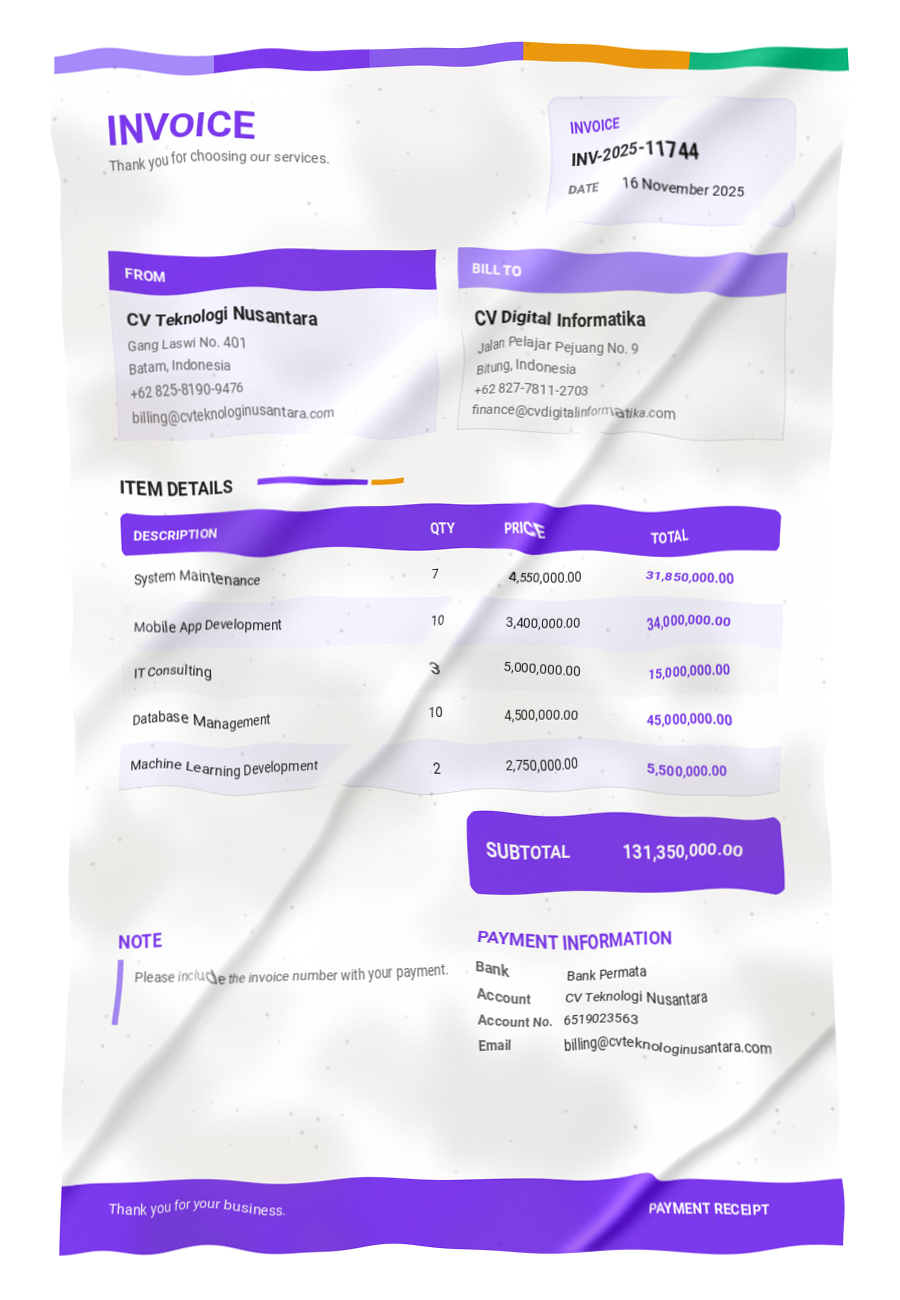

In [19]:
sample['image']

In [20]:
pixel_values = processor(sample['image'],return_tensors="pt").pixel_values.to(device)

In [21]:
task_start_token = "<parsing>"
decoder_input_ids = processor.tokenizer(task_start_token, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

In [22]:
generated_ids = loaded_model.generate(
    pixel_values,
    decoder_input_ids=decoder_input_ids,
    max_length=300,
    bad_words_ids=[[processor.tokenizer.unk_token_id]]
)

In [23]:
print(f'generated tokens count: {len(generated_ids[0])}')
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

generated tokens count: 260


In [24]:
print(generated_text)
processor.token2json(generated_text)

<parsing><s><s_subtotal> 131350000</s_subtotal><s_payment_information><s_email> billing@cvteknologinusantara.com</s_email><s_bank> Bank Permata</s_bank><s_account_number> 6519023563</s_account_number><s_account_name> CV Teknologi Nusantara</s_account_name></s_payment_information><s_note> Please include the invoice number with your payment.</s_note><s_items><s_total> 31850000</s_total><s_qty> 7</s_qty><s_price> 4550000</s_price><s_description> System Maintenance</s_description><sep/><s_total> 34000000</s_total><s_qty> 10</s_qty><s_price> 3400000</s_price><s_description> Mobile App Development</s_description><sep/><s_total> 15000000</s_total><s_qty> 3</s_qty><s_price> 5000000</s_price><s_description> IT Consulting</s_description><sep/><s_total> 45000000</s_total><s_qty> 10</s_qty><s_price> 4500000</s_price><s_description> Database Management</s_description><sep/><s_total> 5500000</s_total><s_qty> 2</s_qty><s_price> 2750000</s_price><s_description> Machine Learning Development</s_descript

{'subtotal': '131350000',
 'payment_information': {'email': 'billing@cvteknologinusantara.com',
  'bank': 'Bank Permata',
  'account_number': '6519023563',
  'account_name': 'CV Teknologi Nusantara'},
 'note': 'Please include the invoice number with your payment.',
 'items': [{'total': '31850000',
   'qty': '7',
   'price': '4550000',
   'description': 'System Maintenance'},
  {'total': '34000000',
   'qty': '10',
   'price': '3400000',
   'description': 'Mobile App Development'},
  {'total': '15000000',
   'qty': '3',
   'price': '5000000',
   'description': 'IT Consulting'},
  {'total': '45000000',
   'qty': '10',
   'price': '4500000',
   'description': 'Database Management'},
  {'total': '5500000',
   'qty': '2',
   'price': '2750000',
   'description': 'Machine Learning Development'}],
 'invoice_no': 'INV-2025-1174',
 'invoice_date': '16 November 2025',
 'from_to': {'phone': '+62 825-8190-9476',
  'name': 'CV Teknologi Nusantara',
  'email': 'billing@cvteknologinusantara.com',
  '